# Example 18: Bayesian Inference

Bayesian inference in linear regression provides a probabilistic approach to modeling and analyzing linear relationships between variables. It differs from traditional (frequentist) linear regression by treating the model parameters as random variables and incorporating prior knowledge through prior distributions.

## Core Concepts

- **Probabilistic Framework**: Bayesian inference uses probability distributions rather than point estimates, offering a more nuanced view of uncertainty in model parameters.
- **Prior Distribution**: Prior beliefs about the parameters (regression coefficients and error variance) are expressed as probability distributions, known as priors. These priors are updated with observed data to get the posterior distributions.
- **Posterior Distribution**: The essence of Bayesian analysis is the posterior distribution, which combines the prior distribution with the likelihood of the observed data. This gives a new distribution reflecting updated knowledge about the parameters after observing data.

## Advantages

- **Incorporation of Prior Knowledge**: Allows the inclusion of existing knowledge or expert opinion in the model, which is particularly useful when data is scarce or expensive to obtain.
- **Handling of Uncertainty**: Provides a more comprehensive understanding of uncertainty in model predictions and parameter estimates.
- **Flexibility**: Can handle complex models and scenarios where traditional methods struggle, like situations with small sample sizes or non-standard assumptions.

## Process

1. **Define Priors**: Set up prior distributions for the parameters (e.g., normal priors for coefficients, inverse gamma for error variance).
2. **Model Specification**: Define the likelihood of the data given the parameters, typically assumed to be normally distributed in linear regression.
3. **Compute Posterior**: Use Bayes' theorem to update the priors with the observed data, resulting in the posterior distribution.
4. **Inference**: Make predictions and infer parameters using the posterior distribution. Often involves generating samples from the posterior using computational techniques like Markov Chain Monte Carlo (MCMC).

In [1]:
# Standard Imports
import numpy as np
import matplotlib.pyplot as plt

# For modeling and evaluation
from scipy.optimize import minimize
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

Here, we use Bayesian inference to construct a linear function. So our synthetic data has the true model of $$Y = 1 + 3X_1 + 2X_2.$$

In [2]:
# Generate synthetic data with multiple features
np.random.seed(18)
n_samples = 100
n_features = 2

# True coefficients
true_coeffs = np.array([3.0, 2.0])
true_intercept = 1.0

# Generate synthetic features
X = np.random.randn(n_samples, n_features)

# Generate synthetic target variable
y = true_intercept + np.dot(X, true_coeffs) + np.random.normal(0, 0.2, 100)

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=18)

The `log_posterior` function calculates the logarithm of the posterior probability of the parameters given data (`X` and `y`).

In [3]:
# Bayesian Linear Regression model specification
def log_likelihood(params, X, y):
    intercept = params[0]
    coeffs = params[1:]
    y_pred = intercept + np.dot(X, coeffs)
    residual = y - y_pred
    log_likelihood = -0.5 * np.sum(residual**2)
    return log_likelihood

def log_prior(params):
    # Assuming uninformative priors (flat priors)
    return 0.0

def log_posterior(params, X, y):
    return log_prior(params) + log_likelihood(params, X, y)

We define a callback function to store the samples used to construct the model. This is not strictly necessary when performing a Bayesian Inference model, but for educational purposes, it is very helpful to see. 

In [4]:
# Define a callback function to store parameters
param_history = []

def callback(params):
    param_history.append(params.copy())


This code is performing a type of optimization known as Maximum A Posteriori (MAP) estimation. It is trying to find the set of parameters (`params`) that maximize the posterior probability of the model given the data. This is a common approach in Bayesian inference, where instead of finding point estimates through maximum likelihood, one looks for parameter values that are most probable given prior information and observed data.

In [5]:
# Maximum A Posteriori (MAP) estimation
initial_guess = np.zeros(n_features + 1) # prior is 0

result = minimize(lambda params: -log_posterior(params, X_train, y_train), initial_guess, 
                  callback=callback, method='TNC')
map_params = result.x

# Summary statistics of MAP estimated coefficients
print("MAP Estimated Coefficients:")
print(map_params)

MAP Estimated Coefficients:
[0.9726811  3.02011102 2.01851844]


We now graph the distributions of the samples when solving for the intercept and coefficients above. `minimize` constructs these coefficients relatively quickly so the samples are small. 

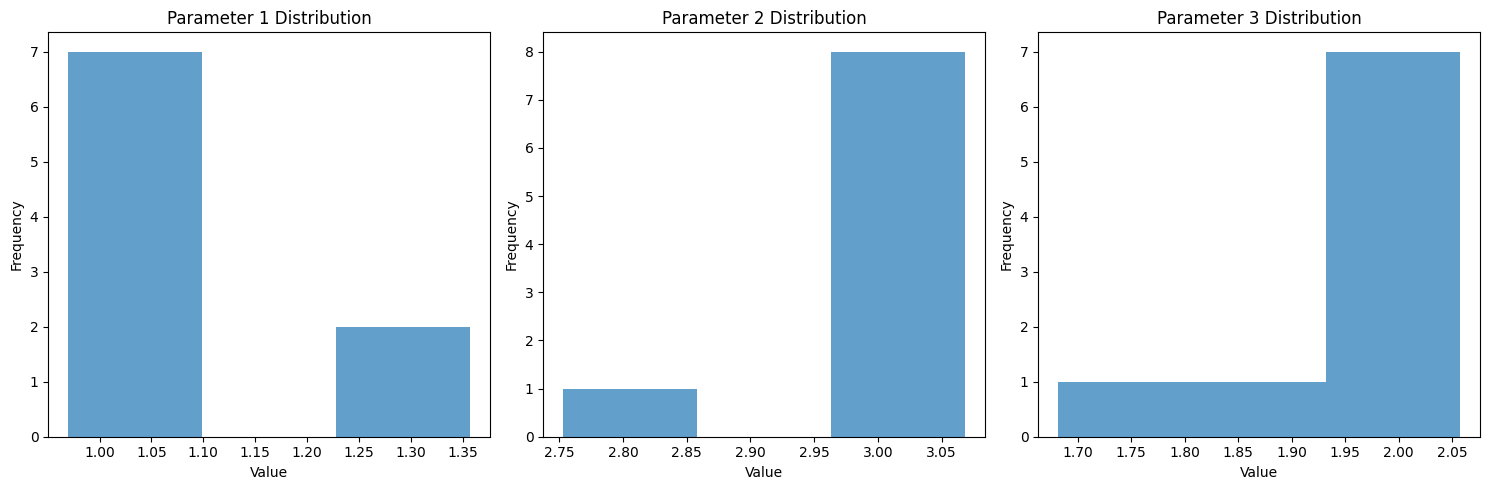

In [6]:
# Assuming param_history is populated as shown in the previous example
param_history = np.array(param_history)  # Convert list to numpy array for easier manipulation

# Number of parameters
num_params = param_history.shape[1]

# Plotting
plt.figure(figsize=(15, 5))
for i in range(num_params):
    plt.subplot(1, num_params, i + 1)
    plt.hist(param_history[:, i], bins=3, alpha=0.7)
    plt.title(f'Parameter {i+1} Distribution')
    plt.xlabel('Value')
    plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

The model constructed with this method is evaluated using the testing set below. 

In [7]:
y_test_pred = map_params[0] + map_params[1]*X_test[:,0] + map_params[2]*X_test[:,1]

mse = mean_squared_error(y_test, y_test_pred)
r2 = r2_score(y_test, y_test_pred)

print(f"Mean Squared Error on testing set: {mse:.4f}")
print(f"R-squared on testing set: {r2:.4f}")

Mean Squared Error on testing set: 0.0369
R-squared on testing set: 0.9977


We can also visualize our against the function. Since this is three dimensional, we provide a contour plot below to represent the plane constructed. 

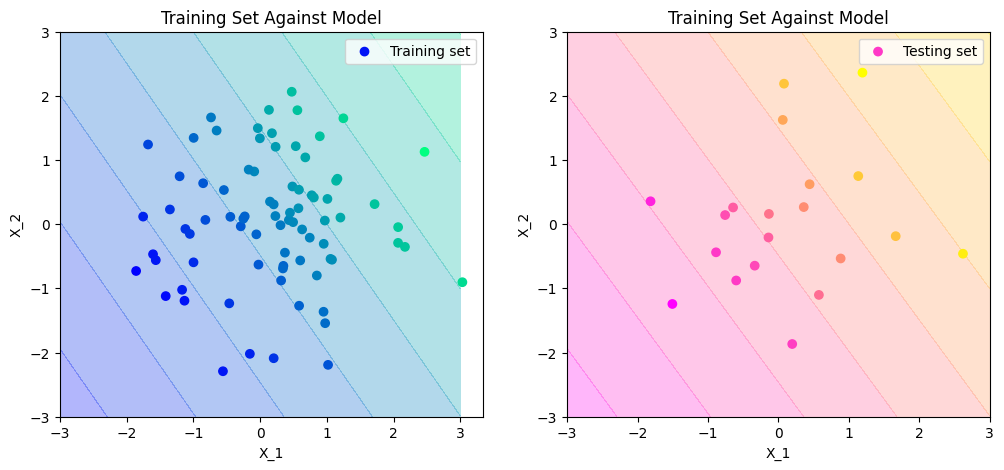

In [8]:
X_range = np.linspace(-3, 3, 250)
X1, X2 = np.meshgrid(X_range, X_range)
Z = map_params[0] + map_params[1]*X1 + map_params[2]*X2

plt.figure(figsize=(12, 5))

# Plot Training Data with function
plt.subplot(121)
plt.contourf(X1, X2, Z, cmap='winter', alpha=0.3)
plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap='winter', label='Training set')
plt.xlabel('X_1')
plt.ylabel('X_2')
plt.title('Training Set Against Model')
plt.legend()

# Plot Testin Data with function
plt.subplot(122)
plt.contourf(X1, X2, Z, cmap='spring', alpha=0.3)
plt.scatter(X_test[:, 0], X_test[:, 1], c=y_test, cmap='spring', label='Testing set')
plt.xlabel('X_1')
plt.ylabel('X_2')
plt.title('Training Set Against Model')
plt.legend()
plt.show()